### **TAYLOR SWIFT**
---
##### Trabajo practico II - Procesamiento del lenguaje natural - ITBA
##### *Embeddings de palabras.*
---
Miembros del grupo:
* Magdalena Eppens - 62450
* Sofía Hanna Feilbogen - 61889
* Sofía Gonzalez del Solar - 62292
* Nicole Reiman - 62407


### 1. Librerias

In [ ]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import string
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from textblob import TextBlob
import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dropout, Dense
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import plotly.graph_objs as go
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
nltk.download('punkt')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import drive as gdrive
gdrive.mount('/content/drive')

Mounted at /content/drive


### 2. Bases de datos

In [ ]:
albums = [
    "01-taylor_swift.csv",
    "02-fearless_taylors_version.csv",
    "03-speak_now_deluxe_package.csv",
    "04-red_deluxe_edition.csv",
    "05-1989_deluxe.csv",
    "06-reputation.csv",
    "07-lover.csv",
    "08-folklore_deluxe_version.csv",
    "09-evermore_deluxe_version.csv"
]

dataframes = []
for album in albums:
    df = pd.read_csv(album)
    df['Album'] = album.replace('.csv', '')
    dataframes.append(df)
merged_df = pd.concat(dataframes, ignore_index=True)

# Se definen los colores de los albumes
albums_colors = {
    "taylor swift": "#50a7e0",
    "fearless taylors version": "#d9c78f",
    "speak now deluxe package": "#632e6d",
    "red deluxe edition": "#a02b48",
    "deluxe": "#d6e9ff",
    "reputation": "#000000",
    "lover": "#d6b0d6",
    "folklore deluxe version": "#bababa",
    "evermore deluxe version": "#523211"
}

### 3. Eliminación de stopwords

In [ ]:
stop_words = set(stopwords.words('english'))
stop_words.discard('he')
stop_words.discard('she')
additional_stopwords = {'oh', 'yet', 'im', 'na', 'eh'}
stop_words.update(additional_stopwords)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

merged_df['lyric'] = merged_df['lyric'].apply(clean_text)
merged_df['track_title'] = merged_df['track_title'].apply(clean_text)
merged_df['album_name'] = merged_df['album_name'].apply(clean_text)

# Se crea un df por frases, y uno por canciones.
df_frases = merged_df
df_canciones = merged_df.groupby(['album_name', 'track_title', 'track_n'])['lyric'].apply(' '.join).reset_index()

### 4. Lematización

##### 1. Función para lemtizar

In [ ]:
# Se realiza lematización, proceso por el cual se busca el lema de una palabra,
# asegurando que el resultado siempre sea una palabra real y considerando el contexto y la gramática.

import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text_with_mapping(text):
    text = text.replace('hes', 'he')
    text = text.replace('wan', 'want')
    text = text.replace('wantna', 'want')
    text = text.replace('wantt', 'want')
    text = text.replace('cause', 'because')
    text = text.replace('youve', 'you')
    text = text.replace('youll', 'you')
    text = text.replace('youd', 'you')
    text = text.replace('youre', 'you')
    text = text.replace('ahah', 'ah')
    text = text.replace('ahahag', 'ah')
    text = text.replace('ahh', 'ah')
    text = text.replace('ahuh', 'ah')

    text = text.replace('applaud', 'applause')
    text = text.replace('asked', 'ask')
    text = text.replace('babe', 'baby')
    text = text.replace('babys', 'baby')
    text = text.replace('building', 'build')
    text = text.replace('burned', 'burn')
    text = text.replace('burnin', 'burn')
    text = text.replace('clearer', 'clear')
    text = text.replace('coast', 'coastal')
    text = text.replace('building', 'build')
    text = text.replace('burned', 'burn')

    text = text.replace('colder', 'cold')
    text = text.replace('complex', 'complicate')
    text = text.replace('confess', 'confession')
    text = text.replace('cruelty', 'cruel')
    text = text.replace('dancing', 'dance')
    text = text.replace('dancin', 'dance')
    text = text.replace('darker', 'dark')
    text = text.replace('darkest', 'dark')
    text = text.replace('darkness', 'dark')
    text = text.replace('darlin', 'darling')
    text = text.replace('deadend', 'dead')
    text = text.replace('died', 'dies')
    text = text.replace('ohoh', 'oh')
    text = text.replace('ohh', 'oh')

    no_lemmatize_words = {'dies', 'pass'}

    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    pos_tag_mapping = {
        'J': nltk.corpus.wordnet.ADJ,
        'V': nltk.corpus.wordnet.VERB,
        'N': nltk.corpus.wordnet.NOUN,
        'R': nltk.corpus.wordnet.ADV
    }
    lemmatized_mapping = []
    for token, pos_tag in pos_tags:
        if token.lower() in no_lemmatize_words:
            lemmatized_token = token
        else:
            wn_pos_tag = pos_tag_mapping.get(pos_tag[0].upper(), nltk.corpus.wordnet.NOUN)
            lemmatized_token = lemmatizer.lemmatize(token, pos=wn_pos_tag)
        lemmatized_mapping.append((token, lemmatized_token))
    lemmatized_text = ' '.join(word[1] for word in lemmatized_mapping)
    return lemmatized_text, lemmatized_mapping

# Vuelvo a eliminar stopwords
stop_words = set(stopwords.words('english'))
stop_words.discard('he')
stop_words.discard('she')
additional_stopwords = {'oh', 'yet', 'im', 'na', 'eh'}
stop_words.update(additional_stopwords)
merged_df['lyric'] = merged_df['lyric'].apply(clean_text)
merged_df['track_title'] = merged_df['track_title'].apply(clean_text)
merged_df['album_name'] = merged_df['album_name'].apply(clean_text)

# Se crea un df por frases, y uno por canciones.
df_frases = merged_df
df_canciones = merged_df.groupby(['album_name', 'track_title', 'track_n'])['lyric'].apply(' '.join).reset_index()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


##### 2. Lematización por frases

In [ ]:
# Se agrega al dataframe una columna que tenga el texto lematizado.
df_frases['lyric_lemmatized'], lyric_lemmatized_mapping_list = zip(*df_frases['lyric'].apply(lemmatize_text_with_mapping))

##### 3. Lematizacion por cancion

In [ ]:
# Se agrega al dataframe una columna que tenga el texto lematizado.
df_canciones['lyric_lemmatized'], lyric_lemmatized_mapping_list = zip(*df_canciones['lyric'].apply(lemmatize_text_with_mapping))

##### 4. ¿Que palabras fueron lematizadas?

In [ ]:
# Funcion para ver que palabras fueron lematizadas
def get_changed_lyrics(mapping_list):
    return [mapping for mapping in mapping_list if mapping[0] != mapping[1]]

changed_lyrics = [get_changed_lyrics(mapping_list) for mapping_list in lyric_lemmatized_mapping_list]
unique_words = set(mapping for sublist in changed_lyrics for mapping in sublist)

# Se crea un df con la palabra original y su lematizacion
df_palabras_lematizadas = pd.DataFrame(list(unique_words), columns=['Original word', 'Lemmatized word'])

### 5. Vectorización de palabras totales


---
Para esta seccion, el corpus es el total de canciones. Es decir, se agarran todas las palabras que aparecen en todas las letras, y se vectorizan.


##### 5.1. Se guardan las palabras en vectores

In [ ]:
palabras_unicas = set()
for lyrics in df_canciones['lyric_lemmatized']:
    words = lyrics.split()
    palabras_unicas.update(words)

# Palabras unicas de los albumes de Taylor
palabras_unicas = sorted(list(palabras_unicas))

# Para ver cuantas palabras unicas hay:
print("Cantidad de palabras unicas:",len(palabras_unicas))

# Se transforman todas las palabras a vectores
# Elegir la dimension del embedding
embedding_size = 150
model = Word2Vec(sentences=[palabras_unicas], vector_size=embedding_size, window=5, min_count=1, sg=1)

vector_palabras = {}
for palabra in palabras_unicas:
    if palabra in model.wv:
        vector_palabras[palabra] = model.wv[palabra]
    else:
        vector_palabras[palabra] = np.zeros(embedding_size)

# Convertir el diccionario a un DataFrame
df_vector_palabras = pd.DataFrame.from_dict(vector_palabras, orient='index')

Cantidad de palabras unicas: 2694


##### 5.2. Palabras mas repetidas en total

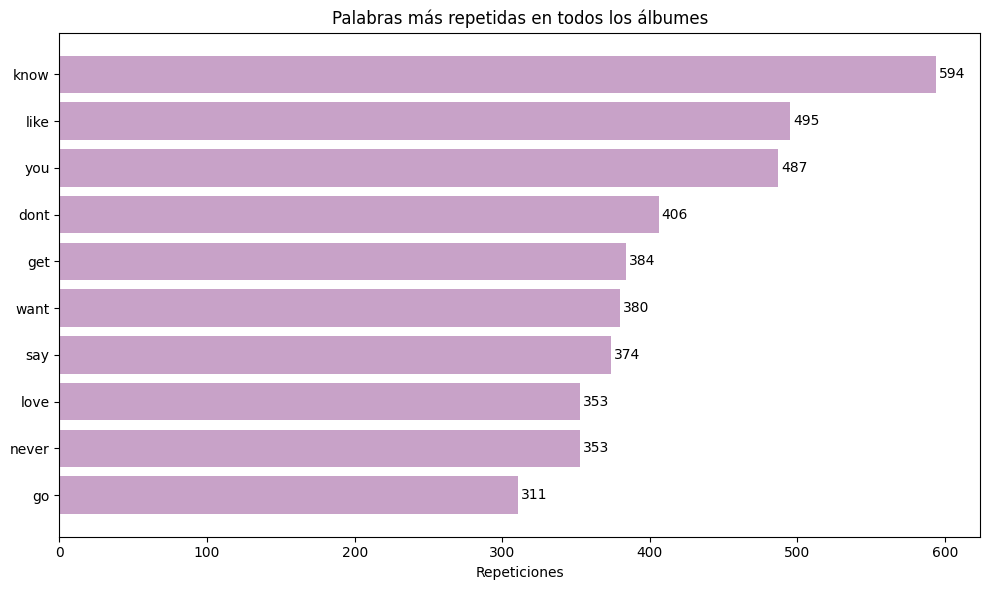

In [ ]:
def tokenize(text):
    tokens = word_tokenize(text.lower())
    return tokens

def top_words_total(df):
    lyrics = ' '.join(df['lyric_lemmatized'])
    tokens = tokenize(lyrics)
    word_counts = Counter(tokens)
    top_words_total = word_counts.most_common(10)
    return top_words_total

top_10_words_total = top_words_total(df_canciones)
top10_total = pd.DataFrame(top_10_words_total, columns=['word', 'repetitions'])

# Grafico que muetra las 10 palabras mas repetidas en el total de albumes
plt.figure(figsize=(10, 6))
words = top10_total["word"]
repetitions = top10_total["repetitions"]
bars = plt.barh(words, repetitions, color='#C8A2C8')

for bar, repetition in zip(bars, repetitions):
    plt.text(bar.get_width() + 2,
             bar.get_y() + bar.get_height() / 2,
             repetition,
             va='center',
             color='black')

plt.xlabel('Repeticiones')
plt.title('Palabras más repetidas en todos los álbumes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### 5.3. Vecinos de las palabras mas repetidas

In [ ]:
# Grafico en 2d
top_10_words = top10_total['word'].tolist()
top_10_words_coords = df_vector_palabras.loc[top_10_words]

similar_words_coords = {}
for word, coords in top_10_words_coords.iterrows():
    distances = ((df_vector_palabras - coords) ** 2).sum(axis=1)
    closest_words = distances.sort_values().iloc[1:11]
    similar_words_coords[word] = df_vector_palabras.loc[closest_words.index]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=top_10_words_coords[0],
    y=top_10_words_coords[1],
    mode='text',
    text=top_10_words,
    textposition='top center',
    textfont=dict(size=12, color='fuchsia'),
    showlegend=False
))

for word, coords in similar_words_coords.items():
    fig.add_trace(go.Scatter(
        x=coords[0],
        y=coords[1],
        mode='text',
        text=coords.index,
        textposition='top center',
        textfont=dict(size=10, color='black'),
        showlegend=False
    ))

fig.update_layout(title='Palabras más repetidas y sus palabras cercanas', title_x=0.5)
fig.show()

In [ ]:
import plotly.graph_objs as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=top_10_words_coords[0],
    y=top_10_words_coords[1],
    z=top_10_words_coords[2],
    text=top_10_words,
    mode='text',
    textposition='top center',
    textfont=dict(size=12, color='fuchsia'),
    showlegend=False
))

for word, coords in similar_words_coords.items():
    fig.add_trace(go.Scatter3d(
        x=coords[0],
        y=coords[1],
        z=coords[2],
        text=coords.index,
        mode='text',
        textposition='top center',
        textfont=dict(size=8, color='black'),
        showlegend=False
    ))

fig.update_layout(
    scene=dict(
        xaxis=dict(title='X'),
        yaxis=dict(title='Y'),
        zaxis=dict(title='Z')
    )
)

fig.update_layout(title='Palabras más repetidas y sus palabras cercanas', title_x=0.5)
fig.show()

In [ ]:
# Esta funcion sirve para ingresar una palabra y ver sus vecinos mas cercanos.
def graficar_vecino(word_to_search):
    word_coords = df_vector_palabras.loc[word_to_search]
    distances = ((df_vector_palabras - word_coords) ** 2).sum(axis=1)
    closest_words = distances.sort_values().iloc[1:51]
    neighbors_coords = df_vector_palabras.loc[closest_words.index]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=[word_coords[0]],
        y=[word_coords[1]],
        mode='text',
        text=[word_to_search],
        textposition='top center',
        textfont=dict(size=14, color='fuchsia'),
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=neighbors_coords[0],
        y=neighbors_coords[1],
        mode='text',
        text=neighbors_coords.index,
        textposition='top center',
        textfont=dict(size=8, color='gray'),
        showlegend=False
    ))

    fig.update_layout(title='Palabra: ' + word_to_search, title_x=0.5)
    fig.show()

# Llamar a la función con la palabra a buscar
word_to_search = "he"
graficar_vecino(word_to_search)

### 6. Vectorización de palabras, por album


---
Para esta seccion, el corpus es el total de canciones de cada album. Es decir, se selecciona un album, se agarran todas las palabras que aparecen en todas sus letras, y se vectorizan.

##### 6.1. Preparo los datos

In [ ]:
def top_words_per_album(df):
    top_words_dict = {}
    for album_name in df['album_name'].unique():
        df_album = df[df['album_name'] == album_name]
        lyrics = ' '.join(df_album['lyric_lemmatized'])
        tokens = tokenize(lyrics)
        fdist = FreqDist(tokens)
        top_words = fdist.most_common(10)
        top_words_dict[album_name] = top_words

    return top_words_dict

top_words_per_album = top_words_per_album(df_canciones)

formatted_data = []
for album_name, word_reps in top_words_per_album.items():
    for word, repetitions in word_reps:
        formatted_data.append([album_name, word, repetitions])
top_words_per_album = pd.DataFrame(formatted_data, columns=['album_name', 'word', 'repetitions'])

In [ ]:
def obtener_vectores_album(df, album_name, embedding_size=150):
    df_album = df[df['album_name'] == album_name]

    palabras_unicas = set()
    for lyrics in df_album['lyric_lemmatized']:
        words = lyrics.split()
        palabras_unicas.update(words)

    palabras_unicas = sorted(list(palabras_unicas))

    model = Word2Vec(sentences=[palabras_unicas], vector_size=embedding_size, window=5, min_count=1, sg=1)

    vector_palabras = {}
    for palabra in palabras_unicas:
        if palabra in model.wv:
            vector_palabras[palabra] = model.wv[palabra]
        else:
            vector_palabras[palabra] = np.zeros(embedding_size)

    df_vector_palabras = pd.DataFrame.from_dict(vector_palabras, orient='index')

    df_vector_palabras['album'] = album_name
    df_vector_palabras['word'] = df_vector_palabras.index

    return df_vector_palabras

# Juntar todos los vectores de los diferentes albumes en 1 solo df.
df_vector_palabras_album = obtener_vectores_album(df_canciones, "taylor swift")
df_vector_palabras_album1 =obtener_vectores_album(df_canciones, "fearless taylors version")
df_vector_palabras_album2 = obtener_vectores_album(df_canciones, "evermore deluxe version")
df_vector_palabras_album3 = obtener_vectores_album(df_canciones, "red deluxe edition")
df_vector_palabras_album4 =obtener_vectores_album(df_canciones, "deluxe")
df_vector_palabras_album5 =obtener_vectores_album(df_canciones, "reputation")
df_vector_palabras_album6 = obtener_vectores_album(df_canciones, "lover")
df_vector_palabras_album7 = obtener_vectores_album(df_canciones, "folklore deluxe version")

dfs = [df_vector_palabras_album, df_vector_palabras_album1, df_vector_palabras_album2,
       df_vector_palabras_album3, df_vector_palabras_album4, df_vector_palabras_album5,
       df_vector_palabras_album6, df_vector_palabras_album7]

df_combined = pd.concat(dfs, ignore_index=True)
lista_top10 = top10_total['word'].tolist()

In [ ]:
# Funcion q me devuelve e indice de las palabras mas cercanas en cada album
def vecinos_cercanos(df, word, cant_vecinos):
    filas_seleccionadas = df[df['word'] == word]
    vecinos_por_album = {}

    for album in df['album'].unique():
        filas_album = filas_seleccionadas[filas_seleccionadas['album'] == album]
        vecinos_album = filas_album.iloc[:, :-2].apply(lambda x: x.nlargest(cant_vecinos).index.tolist(), axis=1)
        vecinos_por_album[album] = vecinos_album.tolist()

    df_vecinos = pd.DataFrame(vecinos_por_album)
    df_vecinos['word'] = word

    return df_vecinos

# Ejemplo de uso
df_resultado1 = vecinos_cercanos(df_combined, 'never', 5)
df_resultado2 = vecinos_cercanos(df_combined, 'love', 5)
df_resultado = pd.concat([df_resultado1, df_resultado2], ignore_index=True)
df_resultado

,taylor swift,fearless taylors version,evermore deluxe version,red deluxe edition,deluxe,reputation,lover,folklore deluxe version,word
0,"[89, 121, 11, 122, 138]","[58, 28, 139, 73, 14]","[83, 114, 97, 4, 67]","[129, 66, 19, 8, 121]","[107, 12, 98, 18, 137]","[147, 74, 97, 86, 120]","[141, 44, 132, 109, 138]","[80, 35, 19, 132, 133]",never
1,"[148, 33, 46, 60, 14]","[33, 143, 48, 93, 84]","[34, 93, 84, 30, 13]","[133, 119, 122, 75, 143]","[22, 122, 135, 110, 127]","[25, 24, 111, 73, 15]","[145, 102, 41, 22, 84]","[141, 57, 100, 31, 97]",love


##### 6.2. Representacion 2D

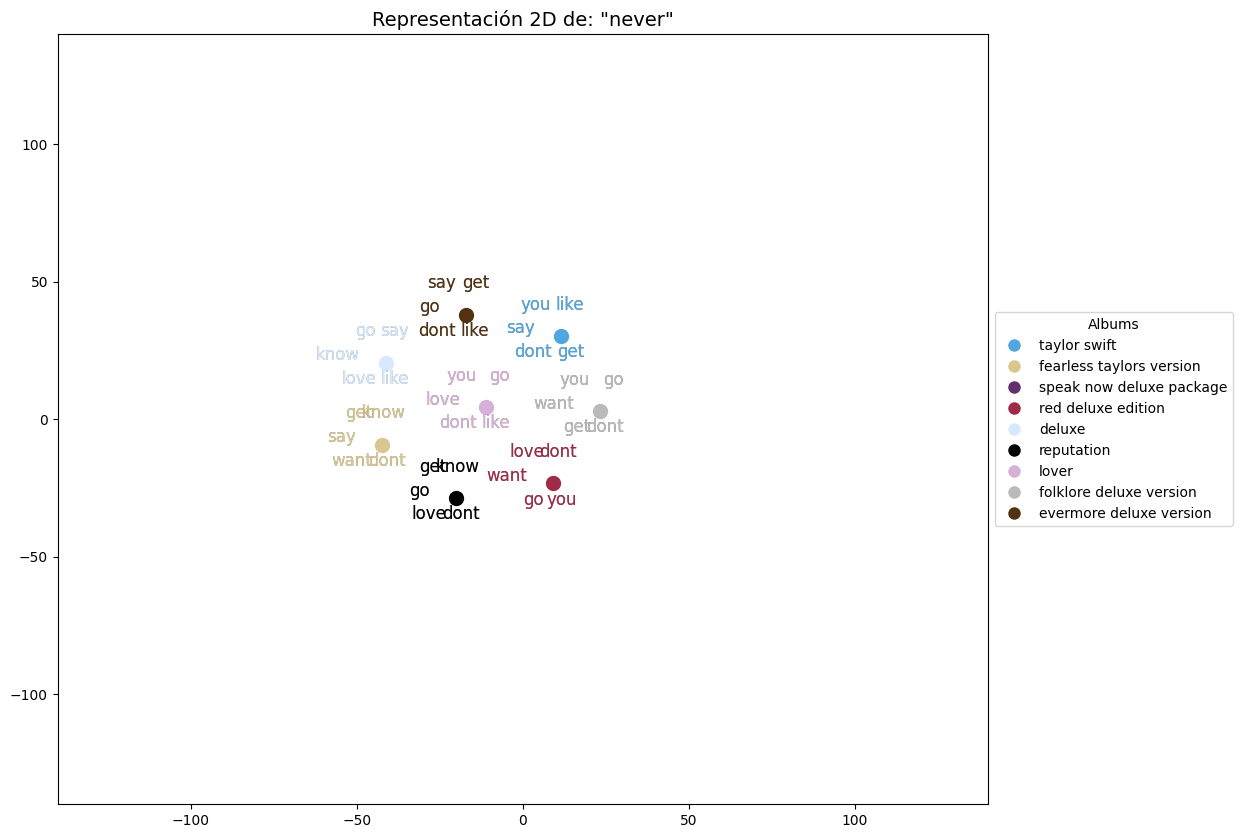

In [ ]:
def find_closest_words(df, word, album, n=5):
    df_album = df[(df['word'] != word) & (df['album'] == album)]
    word_vector = df[df['word'] == word][df.columns[:-2]].values[0].reshape(1, -1)
    album_vectors = df_album[df.columns[:-2]].values

    similarities = cosine_similarity(word_vector, album_vectors)[0]
    closest_indices = similarities.argsort()[-n:][::-1]

    closest_words = df_album.iloc[closest_indices]['word'].tolist()
    return closest_words

def plot_word_vectors(df, word):
    df_word = df[df['word'] == word]
    vector_columns = df.columns[:-2]

    vectors = df_word[vector_columns].values
    albums = df_word['album'].values

    perplexity = min(30, len(vectors) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    vectors_2d = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 10))

    for i, album in enumerate(albums):
        plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1], color=albums_colors[album], s=100, zorder=2)

        closest_words = find_closest_words(df, word, album)
        angle = 0
        for j, closest_word in enumerate(closest_words):
            angle += 360 / (len(closest_words) + 1)
            x = vectors_2d[i, 0] + np.cos(np.radians(angle)) * 10
            y = vectors_2d[i, 1] + np.sin(np.radians(angle)) * 10
            # Se agrega sombra simulada a las palabras anotadas
            plt.annotate(closest_word, (x, y), xytext=(5, 2),
                         textcoords='offset points', ha='right', fontsize=12, color='black', alpha=0.5)  # alpha controla la transparencia

            plt.annotate(closest_word, (x, y), xytext=(5, 2),
                         textcoords='offset points', ha='right', fontsize=12, color=albums_colors[album])

    plt.title(f'Representación 2D de: "{word}"', fontsize=14)

    plt.xlim(-140, 140)
    plt.ylim(-140, 140)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in albums_colors.values()]
    labels = albums_colors.keys()
    plt.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Albums", fontsize=10)

    plt.show()


# Seleccionar aquí la palabra
word = 'never'
plot_word_vectors(df_combined, word)



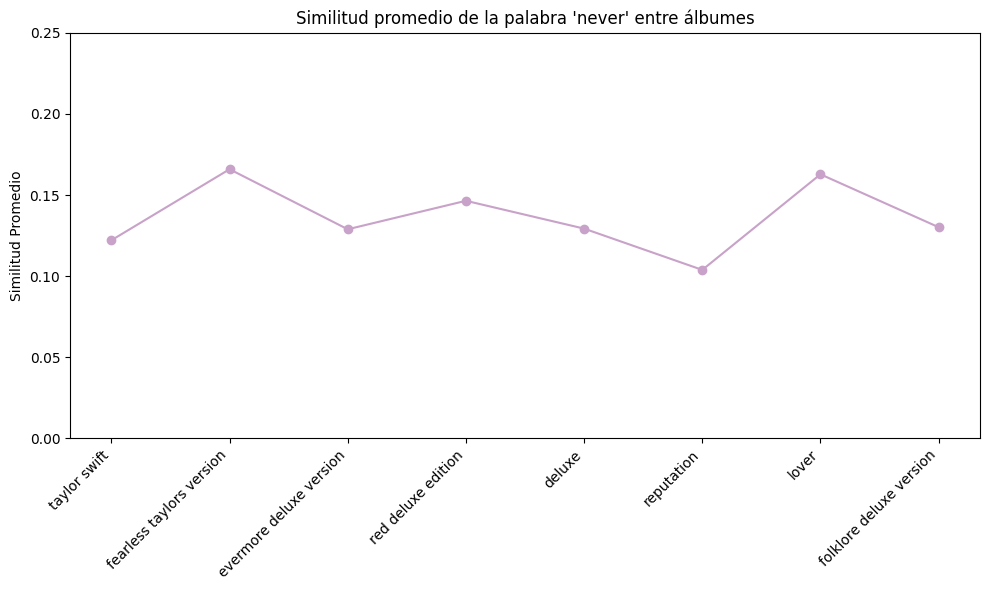

In [ ]:
# Funcion que calcula la similitud de 1 palabr en diferentes albumes
def similitud_palabra_entre_albumes(df_combined, palabra):
    filas_con_palabra = df_combined[df_combined['word'] == palabra]
    filas_con_palabra = filas_con_palabra.drop(columns=['album', 'word'])
    matriz_palabra = filas_con_palabra.to_numpy()
    similitudes = cosine_similarity(matriz_palabra)
    return similitudes

# Función para graficar las similitudes:
def similitud_palabra_entre_albumes(df_combined, palabra):
    filas_con_palabra = df_combined[df_combined['word'] == palabra]
    filas_con_palabra = filas_con_palabra.drop(columns=['album', 'word'])
    matriz_palabra = filas_con_palabra.to_numpy()
    similitudes = cosine_similarity(matriz_palabra)
    return similitudes

# Seleccionar la palabra
palabra = 'never'
similitudes = similitud_palabra_entre_albumes(df_combined, palabra)
promedios_similitud = np.mean(similitudes, axis=1)
albumes = df_combined['album'].unique()

plt.figure(figsize=(10, 6))
plt.plot(albumes, promedios_similitud, marker='o', linestyle='-', color='#C8A2C8')  # Cambiar a plot para convertirlo en un gráfico de series de tiempo
plt.title("Similitud promedio de la palabra '" + palabra + "' entre álbumes")
plt.ylabel('Similitud Promedio')
plt.ylim(0, 0.25)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Representacion 3D

In [ ]:
def plot_word_vectors_3d_interactive(df, word, num_closest=5):
    df_word = df[df['word'] == word]
    vector_columns = df.columns[:-2]

    vectors = df_word[vector_columns].values
    albums = df_word['album'].values

    perplexity = min(30, len(vectors) - 1)
    tsne = TSNE(n_components=3, perplexity=perplexity, random_state=42)
    vectors_3d = tsne.fit_transform(vectors)

    fig = go.Figure()

    for i, album in enumerate(albums):
        fig.add_trace(go.Scatter3d(
            x=[vectors_3d[i, 0]],
            y=[vectors_3d[i, 1]],
            z=[vectors_3d[i, 2]],
            mode='markers',
            marker=dict(
                size=8,
                color=albums_colors[album],
                opacity=0.8
            ),
            name=album
        ))

        # Agregar etiquetas de texto para las palabras más cercanas
        for j in range(num_closest):
            col_index = -(j + 1)  # Índice de columna dinámico
            closest_word = df_word.iloc[i, col_index]  # Obtener la palabra más cercana de la fila actual
            if j == 0:  # Solo añadir leyenda para la primera palabra más cercana
                fig.add_trace(go.Scatter3d(
                    x=[],
                    y=[],
                    z=[],
                    mode='markers',
                    marker=dict(size=0),
                    name=closest_word
                ))

    fig.update_layout(
        title=f'Representación 3D de: "{word}"',
        scene=dict(
            xaxis_title='Dimensión 1',
            yaxis_title='Dimensión 2',
            zaxis_title='Dimensión 3'
        ),
        legend=dict(
            title='Palabras más cercanas'
        )
    )

    fig.show()

# Ejemplo de uso
word = 'never'
plot_word_vectors_3d_interactive(df_combined, word, num_closest=5)

